## Ensemble refinement on-the-fly
described in the Chapter 2 of the Thesis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import copy

In [2]:
import sys
sys.path.append('../')

from simpleMD import generate_chain, SimpleMD

### 1. MD simulation for the prior model
run a new simulation or load pre-existing simulation from `data`

In [3]:
cell = (100., 100., 100.)
positions = generate_chain(10, 1.)

In [4]:
keys_prior = {
 'temperature' : 0.722,
 'tstep' : 0.001,
 'friction' : 1.0,
 'forcecutoff' : 2.5,
 'k_fene' : 30.0,
 'maxbond' : 1.5,
 'q_SAXS' : [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
 'listcutoff' : 3.0,
 'nstep' : 1000000,
 'nconfig' : 1000,
 'nstat' : 100,
 'nequilib' : 10000,
 # pass the crystal lattice generated above
 'cell' : cell,
 'positions' : positions
 }

In [5]:
is_run = False

- if `is_run`, then the `keys_prior` (or following ones) dict is used to run a `SimpleMD` simulation
- else, it loads data from previously generated `SimpleMD` simulation (`data` directory)

In [6]:
if is_run:
    # create runner
    smd_prior = SimpleMD(**keys_prior)
    # run
    smd_prior.run()
else:
    with open("../data/prior.pkl", "rb") as file:
        smd_prior = pickle.load(file)

### 2. MD simulation for the test (reference) model
run a new simulation or load pre-existing simulation from `data`

In [7]:
keys_test = copy.deepcopy(keys_prior)

keys_test.update({
    'k_angle' : 5.0,
    'nconfig' : 100,
    'nstat' : 10
})

In [8]:
if is_run:
    # create runner
    smd_test = SimpleMD(**keys_test)
    # run
    smd_test.run()
else:
    with open("../data/test.pkl", "rb") as file:
        smd_test = pickle.load(file)

### 3. plots

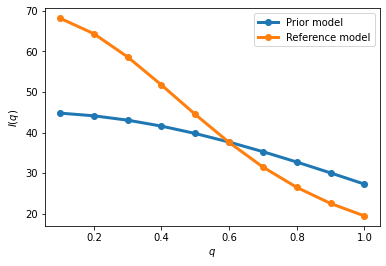

In [9]:
plt.plot(smd_prior.q_SAXS, smd_prior.SAXS, 'o-', label='Prior model', linewidth=3)
plt.plot(smd_test.q_SAXS, 1.5*smd_test.SAXS + 2.0, 'o-', label='Reference model', linewidth=3)
plt.legend()
plt.xlabel(r'$q$')
plt.ylabel(r'$I(q)$')
plt.show()

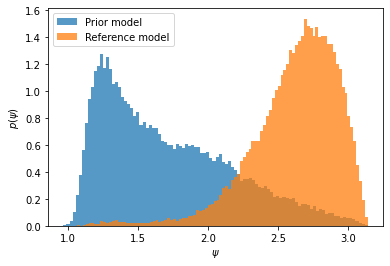

In [10]:
plt.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
plt.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Reference model')
plt.legend()
plt.xlabel(r'$\psi$')
plt.ylabel(r'$p(\psi)$')
plt.show()

### 4. refinement on-the-fly
compare different values of the parameters

In [11]:
keys_l0 = copy.deepcopy(keys_prior)

keys_l0.update({
    'nstep' : int(301e4),
    'exp_SAXS' : smd_test.SAXS,
    'k_SAXS': 0.2,
    'tau_SAXS': 50000.0,
    'sigma_SAXS': [1.0],
    'nonthefly' : int(2e6),
    'l_rgyr2' : 0.
})

In [12]:
keys_l1 = copy.deepcopy(keys_l0)
keys_l1['k_SAXS'] = 2e-3

keys_l2 = copy.deepcopy(keys_l0)
keys_l2['tau_SAXS'] = 500.0

keys_l3 = copy.deepcopy(keys_l0)
keys_l3['k_SAXS'] = 20

keys_l4 = copy.deepcopy(keys_l0)
keys_l4['k_SAXS'] = 2e-3

In [13]:
if is_run:
    smd_l0 = SimpleMD(**keys_l0)
    smd_l0.run()

    smd_l1 = SimpleMD(**keys_l1)
    smd_l1.run()

    smd_l2 = SimpleMD(**keys_l2)
    smd_l2.run()

    smd_l3 = SimpleMD(**keys_l3)
    smd_l3.run()

    smd_l4 = SimpleMD(**keys_l4)
    smd_l4.run()

else:
    with open("../data/posterior_0.2_50000.pkl", "rb") as file:
        smd_l0 = pickle.load(file)

    with open("../data/posterior_0.2_5000000.pkl", "rb") as file:
        smd_l1 = pickle.load(file)

    with open("../data/posterior_0.2_500.pkl", "rb") as file:
        smd_l2 = pickle.load(file)

    with open("../data/posterior_20_50000.pkl", "rb") as file:
        smd_l3 = pickle.load(file)

    with open("../data/posterior_0.002_50000.pkl", "rb") as file:
        smd_l4 = pickle.load(file)

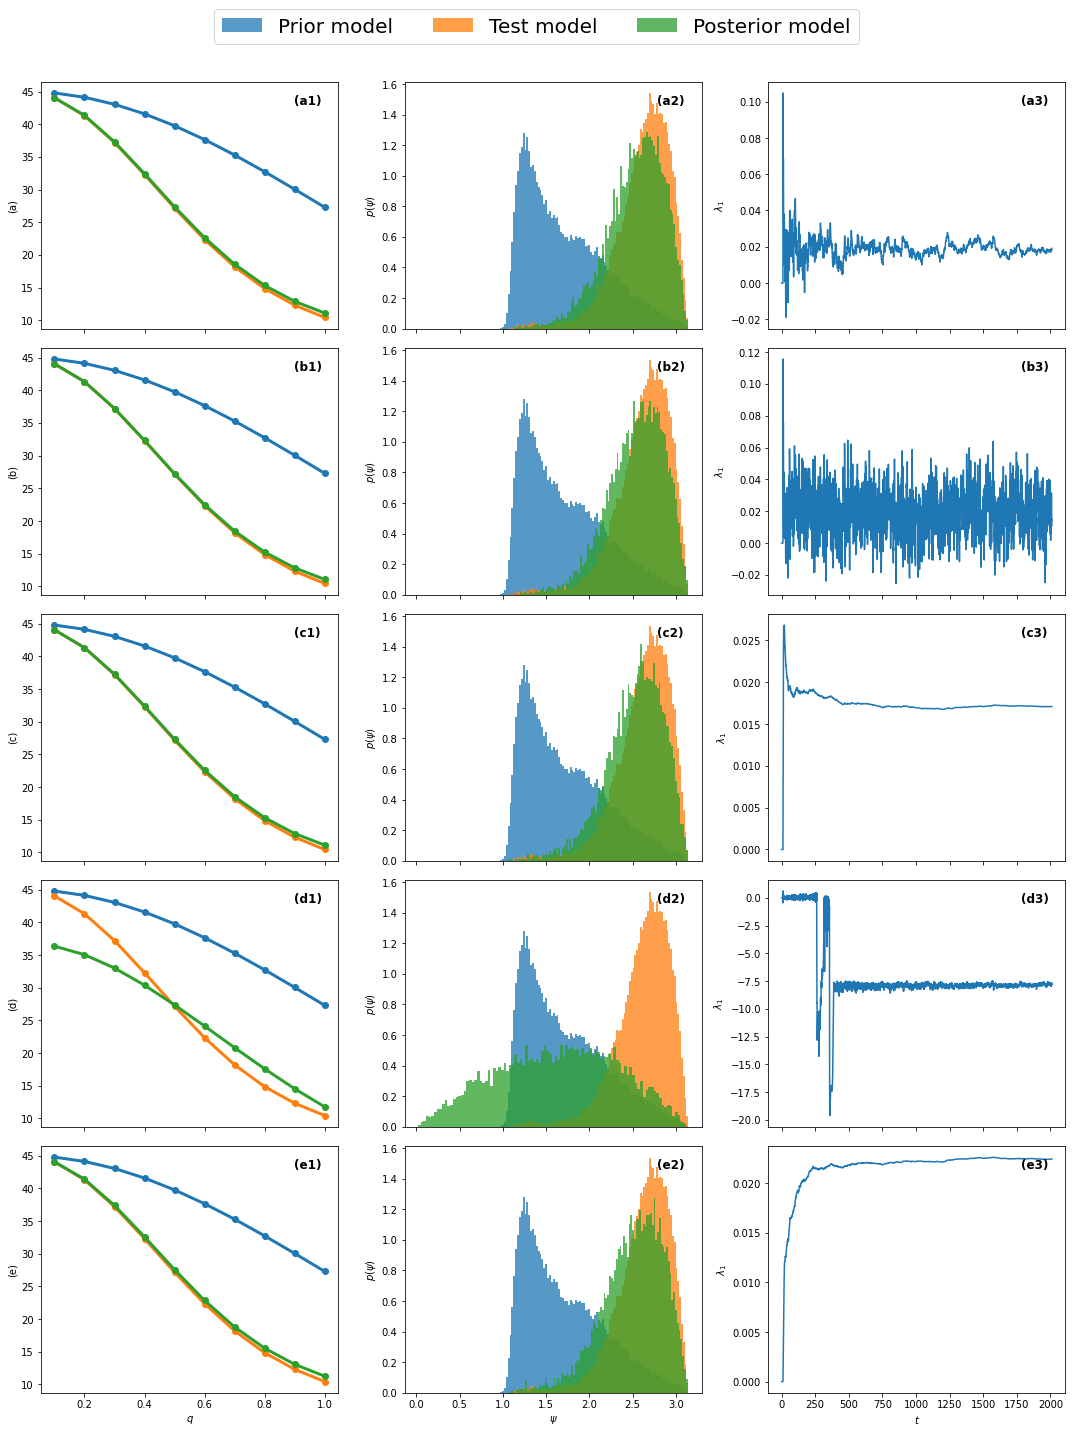

In [14]:
simulations = ["(a)", "(b)", "(c)", "(d)", "(e)"]
image_types = ["Tipo1", "Tipo2", "Tipo3"]
labels = [['(a1)','(a2)','(a3)'], ['(b1)','(b2)','(b3)'], ['(c1)','(c2)','(c3)'], ['(d1)','(d2)','(d3)'], ['(e1)','(e2)','(e3)']] 


fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20), sharex="col")


for i, sim in enumerate(simulations):
  for j, img_type in enumerate(image_types):
    ax = axes[i, j]

    if j == 0:
      if i==0:
        ax.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
        ax.plot(smd_test.q_SAXS, smd_l0.exp_SAXS, '-o', label='Test model',linewidth=3)
        ax.plot(smd_l0.q_SAXS, smd_l0.SAXS, '-o', label='Posterior model',linewidth=3)
        ax.set_ylabel(r'$I(q)$')

      elif i==1:
        ax.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
        ax.plot(smd_test.q_SAXS, smd_l1.exp_SAXS, '-o', label='Test model',linewidth=3)
        ax.plot(smd_l1.q_SAXS, smd_l1.SAXS, '-o', label='Posterior model',linewidth=3)
        ax.set_ylabel(r'$I(q)$')


      elif i==2:
        ax.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
        ax.plot(smd_test.q_SAXS, smd_l2.exp_SAXS, '-o', label='Test model',linewidth=3)
        ax.plot(smd_l2.q_SAXS, smd_l2.SAXS, '-o', label='Posterior model',linewidth=3)
        ax.set_ylabel(r'$I(q)$')

      elif i==3:
        ax.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
        ax.plot(smd_test.q_SAXS, smd_l3.exp_SAXS, '-o', label='Test model',linewidth=3)
        ax.plot(smd_l3.q_SAXS, smd_l3.SAXS, '-o', label='Posterior model',linewidth=3)
        ax.set_ylabel(r'$I(q)$')

      elif i==4:
        ax.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
        ax.plot(smd_test.q_SAXS, smd_l4.exp_SAXS, '-o', label='Test model',linewidth=3)
        ax.plot(smd_l4.q_SAXS, smd_l4.SAXS, '-o', label='Posterior model',linewidth=3)
        ax.set_ylabel(r'$I(q)$')
      
      if j == 0:
        ax.set_ylabel(sim)
    elif j == 1: 
        if i == 0: 
            ax.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
            ax.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Test model')
            ax.hist(smd_l0.angle[5][-10000:], bins=100, density=True, alpha=0.75, label='Posterior model')
            ax.set_ylabel(r'$p(\psi)$')
            
        elif i == 1: 
            ax.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
            ax.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Test model')
            ax.hist(smd_l1.angle[5][-10000:], bins=100, density=True, alpha=0.75, label='Posterior model') 
            ax.set_ylabel(r'$p(\psi)$')
            
        elif i == 2: 
            ax.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
            ax.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Test model')
            ax.hist(smd_l2.angle[5][-10000:], bins=100, density=True, alpha=0.75, label='Posterior model') 
            ax.set_ylabel(r'$p(\psi)$')

        elif i == 3: 
            ax.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
            ax.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Test model')
            ax.hist(smd_l3.angle[5][-10000:], bins=100, density=True, alpha=0.75, label='Posterior model') 
            ax.set_ylabel(r'$p(\psi)$')

        elif i == 4: 
            ax.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
            ax.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Test model')
            ax.hist(smd_l4.angle[5][-10000:], bins=100, density=True, alpha=0.75, label='Posterior model') 
            ax.set_ylabel(r'$p(\psi)$')

        
    elif j == 2: 
        if i == 0:
            ax.plot(np.array(smd_l0.statistics).T[1][:20100],smd_l0.lambda_otf[0][:20100])
            ax.set_ylabel(r'$\lambda_1$')
            
        elif i == 1:
            ax.plot(np.array(smd_l1.statistics).T[1][:20100],smd_l1.lambda_otf[0][:20100])
            ax.set_ylabel(r'$\lambda_1$')
        elif i == 2:
            ax.plot(np.array(smd_l2.statistics).T[1][:20100],smd_l2.lambda_otf[0][:20100])
            ax.set_ylabel(r'$\lambda_1$')

        elif i == 3:
          ax.plot(np.array(smd_l3.statistics).T[1][:20100],smd_l3.lambda_otf[0][:20100])
          ax.set_ylabel(r'$\lambda_1$')

        elif i == 4:
          ax.plot(np.array(smd_l4.statistics).T[1][:20100],smd_l4.lambda_otf[0][:20100])
          ax.set_ylabel(r'$\lambda_1$')


    # Add custom label at the top left of the subplot
    ax.text(0.85, 0.95, labels[i][j], transform=ax.transAxes, fontsize=12, fontweight='bold', va='top')



axes[-1, 0].set_xlabel(r'$q$')
axes[-1, 1].set_xlabel(r'$\psi$')
axes[-1, 2].set_xlabel(r'$t$')



handles, labels_legend = axes[0,1].get_legend_handles_labels() 
fig.legend(handles, labels_legend, loc="upper center", ncol=3,fontsize=20)


plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

#### Select a suitable `keys`

let's choose `keys_l0`

In [15]:
if is_run:
    # create runner
    smd_posterior = SimpleMD(**keys_l0)
    # run
    smd_posterior.run()
else:
    with open("../data/posterior_0.2_50000.pkl", "rb") as file:
        smd_posterior = pickle.load(file)

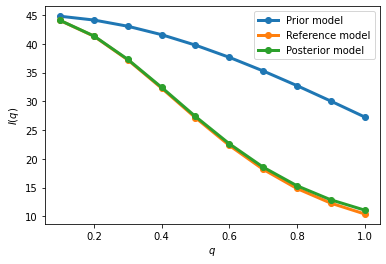

In [16]:
plt.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model', linewidth=3)
plt.plot(smd_posterior.q_SAXS, smd_posterior.exp_SAXS, '-o', label='Reference model', linewidth=3)
plt.plot(smd_posterior.q_SAXS, smd_posterior.SAXS, '-o', label='Posterior model', linewidth=3)
plt.legend()
plt.xlabel(r'$q$')
plt.ylabel(r'$I(q)$')


# plt.savefig('SAXSlfinal.pdf', format='pdf', bbox_inches='tight')

plt.show()

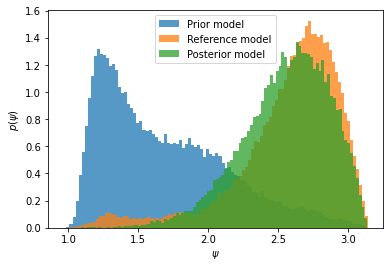

In [17]:
ndata = smd_posterior.nstep - smd_posterior.nonthefly - smd_posterior.nequilib  # data collection phase

plt.hist(smd_prior.angle[3], bins=100, density=True, alpha=0.75, label='Prior model')
plt.hist(smd_test.angle[3], bins=100, density=True, alpha=0.75, label='Reference model')
plt.hist(smd_posterior.angle[3][-ndata:], bins=100, density=True, alpha=0.75, label='Posterior model')
plt.xlabel(r'$\psi$')
plt.ylabel(r'$p(\psi)$')
plt.legend()


plt.show()

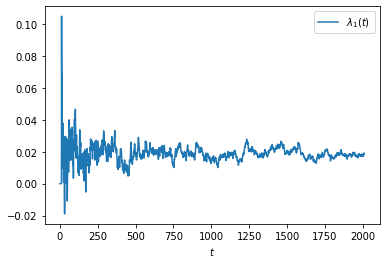

In [18]:
t = np.array(smd_posterior.statistics).T[1][:-ndata//smd_posterior.nstat]
lambda0 = smd_posterior.lambda_otf[0][:-ndata//smd_posterior.nstat]

plt.plot(t, lambda0, label=r"$\lambda_1(t)$")
plt.legend()
plt.xlabel(r'$t$')
# plt.savefig('lfinal.pdf', format='pdf', bbox_inches='tight')
plt.show()


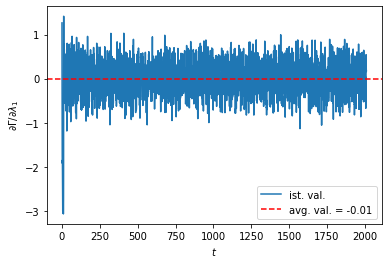

In [19]:
grad = smd_posterior.grad_lambda[1][:-ndata//smd_posterior.nstat]

plt.plot(t, grad, label="ist. val.")
avg=np.mean(grad)
plt.axhline(y=avg, color="r", linestyle="--", label=f"avg. val. = {avg:.2f}")
plt.legend()
plt.xlabel(r'$t$')
plt.ylabel(r'$\partial \Gamma /\partial \lambda_1$') 
plt.show()